<img src="https://raw.githubusercontent.com/drdave-teaching/OPIM5509-notebooks/main/_banners/opim5509_banner.svg" width="100%" alt="OPIM 5509 banner"/>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Multivariate_Occupancy_RNN_pt2.ipynb)

# Multivariate Occupancy RNN, Part 2: Reload and Test on Unseen Data
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Part 1 trained on two weeks of sensor data and saved the stacked RNN. The UCI dataset ships a **third file** - two more days the model has never seen (`datatest.txt`). This notebook downloads the saved model, scores those unseen days, and then explains the classifier: which **sensor** it trusts, which **minutes** of the window it reads, and what happens when you crank the CO2.

No training here. Everything is inference on an artifact.

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 10-pt2 — Multivariate RNN Pt 2b: reload the classifier, score two unseen days, explain it
- Download the .keras Part 1 saved; rebuild the windows the same way (10 minutes, 5 sensors, occupancy last). Prove it still gives Part 1's numbers on Part 1's test split.
- Unseen data: datatest.txt - two days the model never met (they're from BEFORE the training week; fine for a nowcast, and say why it would NOT be fine for a forecast). 97.4% accuracy on the unseen days vs 94.1% on Part 1's split - and persistence is still 0.99 weighted F1. Read the confusion matrix against persistence again.
- Permutation by sensor: shuffle Light across windows and the classifier collapses; shuffle Temperature and nothing happens. The model found the light switch. Ask: is that a good feature or a shortcut? (Night-time meetings...)
- Occlusion by minute: which of the ten minutes matter? For a nowcast it's the LAST minute; the window barely helps. Connect to the persistence baseline being 99%.
- What-if: +300 ppm CO2 moves P(occupied) by +0.008; +200 lux moves it +0.147 and flips 5% of windows; +2 C does nothing. Counterfactuals are the interpretability tool managers actually understand.
-->


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from urllib.request import urlretrieve
from sklearn.metrics import mean_absolute_error, classification_report, confusion_matrix, f1_score
from keras.models import load_model
import keras
keras.utils.set_random_seed(5509)

## Rebuild Part 1's prep, then load the unseen file the same way

In [2]:
base = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/"
def prep(files):
    d = pd.concat([pd.read_csv(base + f) for f in files], ignore_index=True).sort_values("date").reset_index(drop=True)
    return d.drop(columns=["date"])                    # Temperature, Humidity, Light, CO2, HumidityRatio, Occupancy (LAST)

def split_sequences(sequences, n_steps):
    X, y = [], []
    for i in range(len(sequences)):
        end_ix = i + n_steps
        if end_ix > len(sequences): break
        X.append(sequences[i:end_ix, :-1]); y.append(sequences[end_ix-1, -1])   # sensors in, occupancy NOW out (a nowcast)
    return np.array(X), np.array(y)

n_steps = 10
df = prep(["datatraining.txt", "datatest2.txt"])        # Part 1's two weeks
sensors = list(df.columns[:-1])
X, y = split_sequences(df.values, n_steps)
cut = int(0.5 * len(X)); X_test, y_test = X[cut:], y[cut:]

new = prep(["datatest.txt"])                            # the third file: two days the model has never seen
X_new, y_new = split_sequences(new.values, n_steps)
print("Part 1 test:", X_test.shape, "| unseen:", X_new.shape, "| unseen occupied share:", round(y_new.mean(), 2))

Part 1 test: (8943, 10, 5) | unseen: (2656, 10, 5) | unseen occupied share: 0.36


## Download the saved model and prove it's the same one

In [3]:
urlretrieve("https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/models/Multivariate_Occupancy_RNN.keras", "Multivariate_Occupancy_RNN.keras")      # the file the previous notebook saved - now a course asset
model = load_model("Multivariate_Occupancy_RNN.keras")
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 10, 30)         │         1,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,825 (34.48 KB)

 Trainable params: 2,941 (11.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,884 (22.99 KB)

In [4]:
p_test = np.round(model.predict(X_test, verbose=0)).ravel()
print("Part 1's test split, reloaded model:")
print(classification_report(y_test, p_test, digits=3))

Part 1's test split, reloaded model:
              precision    recall  f1-score   support

         0.0      0.963     0.963     0.963      7108
         1.0      0.857     0.855     0.856      1835

    accuracy                          0.941      8943
   macro avg      0.910     0.909     0.909      8943
weighted avg      0.941     0.941     0.941      8943



## Score the unseen days

UNSEEN two days:
[[1636   57]
 [  13  950]]


              precision    recall  f1-score   support

         0.0      0.992     0.966     0.979      1693
         1.0      0.943     0.987     0.964       963

    accuracy                          0.974      2656
   macro avg      0.968     0.976     0.972      2656
weighted avg      0.974     0.974     0.974      2656

persistence baseline on the unseen days - weighted F1: 0.990


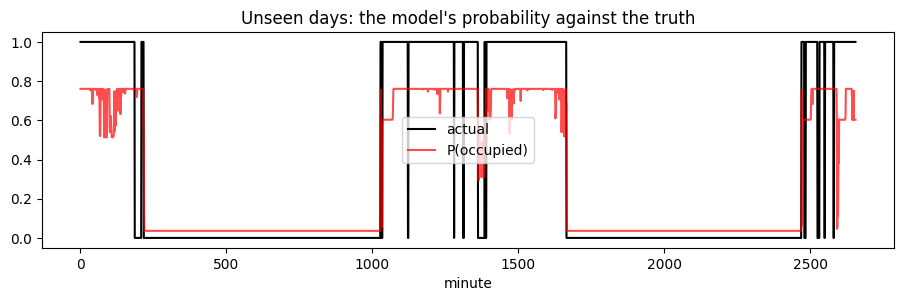

In [5]:
prob_new = model.predict(X_new, verbose=0).ravel()
p_new = np.round(prob_new)
print("UNSEEN two days:")
print(confusion_matrix(y_new, p_new))
print(classification_report(y_new, p_new, digits=3))
persist = np.r_[y_new[0], y_new[:-1]]                                       # "same as a minute ago"
print(f"persistence baseline on the unseen days - weighted F1: {f1_score(y_new, persist, average='weighted'):.3f}")

plt.figure(figsize=(11, 2.8)); plt.plot(y_new, "k", label="actual"); plt.plot(prob_new, "r", alpha=0.7, label="P(occupied)")
plt.title("Unseen days: the model's probability against the truth"); plt.xlabel("minute"); plt.legend(); plt.show()

## 1. Permutation importance by sensor

Shuffle one sensor across the unseen windows and re-score. The F1 that disappears is how much the classifier depended on that sensor.

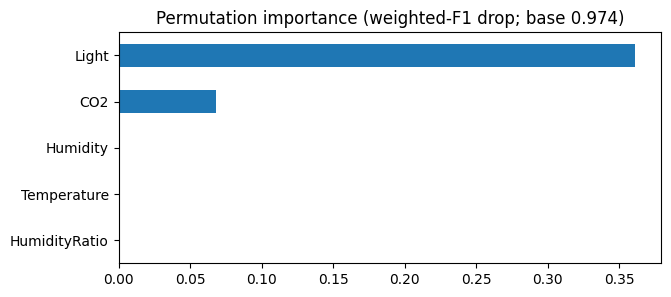

In [6]:
rng = np.random.default_rng(5509)
base_f1 = f1_score(y_new, p_new, average="weighted")
drop = {}
for j, s in enumerate(sensors):
    Xp = X_new.copy(); Xp[:, :, j] = Xp[rng.permutation(len(Xp)), :, j]
    drop[s] = base_f1 - f1_score(y_new, np.round(model.predict(Xp, verbose=0)).ravel(), average="weighted")
pd.Series(drop).sort_values().plot(kind="barh", figsize=(7, 3), title=f"Permutation importance (weighted-F1 drop; base {base_f1:.3f})"); plt.show()

## 2. Occlusion by minute

Blank one minute of the 10-minute window (training-mean sensor readings) and re-score.

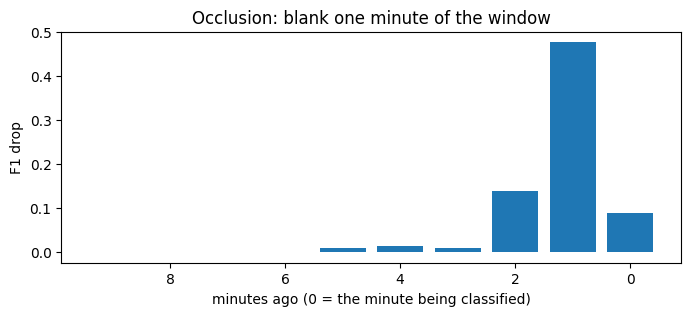

In [7]:
means = X[:cut].reshape(-1, X.shape[2]).mean(axis=0)
occ = []
for t in range(n_steps):
    Xo = X_new.copy(); Xo[:, t, :] = means
    occ.append(base_f1 - f1_score(y_new, np.round(model.predict(Xo, verbose=0)).ravel(), average="weighted"))
mins_ago = np.arange(n_steps - 1, -1, -1)
plt.figure(figsize=(8, 3)); plt.bar(mins_ago, occ); plt.gca().invert_xaxis()
plt.xlabel("minutes ago (0 = the minute being classified)"); plt.ylabel("F1 drop"); plt.title("Occlusion: blank one minute of the window"); plt.show()

## 3. Gradient saliency, sensors x minutes

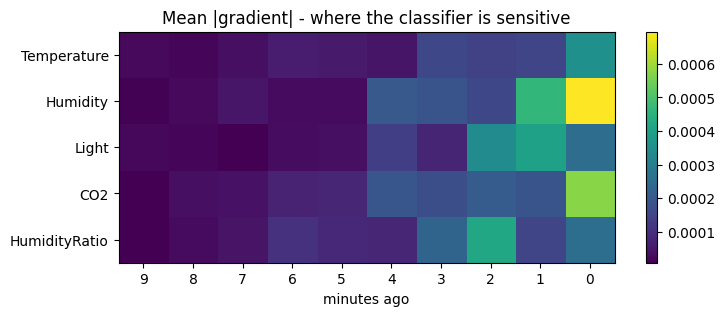

In [8]:
def saliency(model, X):
    x = tf.convert_to_tensor(X, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        out = model(x, training=False)
    return tape.gradient(out, x).numpy()

sal = np.abs(saliency(model, X_new)).mean(axis=0)              # (10, 5)
plt.figure(figsize=(8, 3)); plt.imshow(sal.T, aspect="auto", cmap="viridis"); plt.colorbar()
plt.yticks(range(len(sensors)), sensors); plt.xticks(range(n_steps), mins_ago); plt.xlabel("minutes ago"); plt.title("Mean |gradient| - where the classifier is sensitive"); plt.show()

## 4. What-if: crank the CO2, flip the lights

Add 300 ppm of CO2 to every window and read the change in P(occupied). Then add 200 lux of light. Which one does the model believe?

In [9]:
def whatif(delta, sensor):
    Xw = X_new.copy(); Xw[:, :, sensors.index(sensor)] += delta
    return model.predict(Xw, verbose=0).ravel() - prob_new

for delta, s in [(300, "CO2"), (200, "Light"), (2, "Temperature")]:
    d = whatif(delta, s)
    print(f"+{delta} {s:12s} -> mean change in P(occupied): {d.mean():+.3f}   | share of windows that flip to 'occupied': {((prob_new < 0.5) & (prob_new + d >= 0.5)).mean():.1%}")

+300 CO2          -> mean change in P(occupied): +0.008   | share of windows that flip to 'occupied': 0.6%
+200 Light        -> mean change in P(occupied): +0.147   | share of windows that flip to 'occupied': 5.0%


+2 Temperature  -> mean change in P(occupied): -0.000   | share of windows that flip to 'occupied': 0.0%


## What you just saw

- The reloaded model gives Part 1's numbers **and** holds up on two days it never saw - that is the test that matters.
- It is mostly a **light detector** with CO2 as the second opinion; temperature and humidity barely register. Ask whether that generalizes to a room where people work with the lights off.
- For a *nowcast* the window barely matters - the last minute carries the answer, which is why persistence was 99%. The RNN earns its keep at the **transitions**, when someone walks in or out.

## On your own
- Score `Multivariate_Occupancy_RNN_AdvancedTopics.keras` (the ConvLSTM) on the same unseen days. More parameters, better?
- Shift the target: predict occupancy **5 minutes ahead** (`sequences[end_ix-1+5, -1]`). Now the window should matter - does it?